In [ ]:
Superstore Sales Performance Analysis Using Python

In [35]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('superstore_final_dataset (1).csv', encoding='latin1')
print(df.head())

   Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode Customer_ID  \
0       1  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688   12/6/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer_Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   
4    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   

   Postal_Code Region       Product_ID         Cat

In [26]:
# Convert dates
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)

In [19]:
# Check missing values
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Dataset info
df.info()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row_ID         9800 non-null   int64         
 1   Order_ID       9800 non-null   object        
 2   Order_Date     9800 non-null   datetime64[ns]
 3   Ship_Date      9800 non-null   datetime64[ns]
 4   Ship_Mode      9800 non-null   object        
 5   Customer_ID    9800 non-null   object        
 6   Customer_Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Count

In [22]:
total_revenue = df['Sales'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 2261536.7827000003


In [23]:
total_orders = df['Order_ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 4922


In [24]:
aov = total_revenue / total_orders
print("Average Order Value:", aov)

Average Order Value: 459.4751691791955


Profit Margin and Conversion Metrics could not be calculated because the dataset does not contain Profit or conversion-related fields.

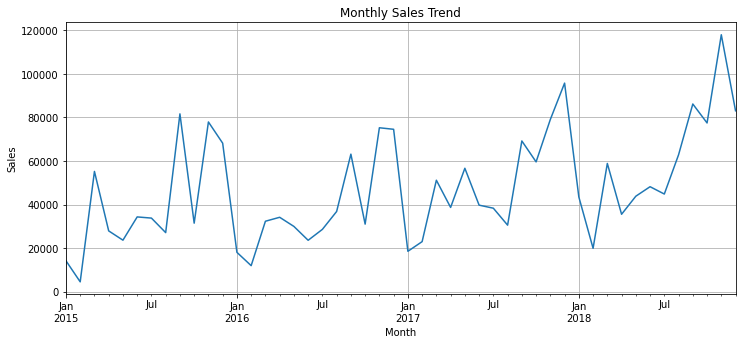

In [28]:
df['Month'] = df['Order_Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

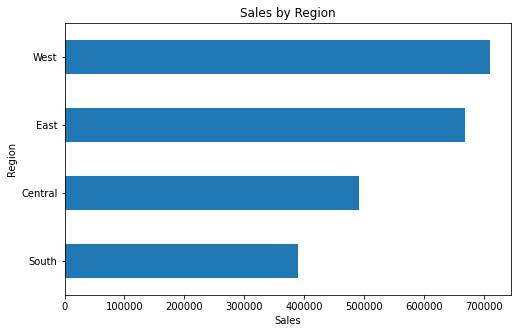

In [29]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

plt.figure(figsize=(8,5))
region_sales.plot(kind='barh')
plt.title('Sales by Region')
plt.xlabel('Sales')
plt.show()

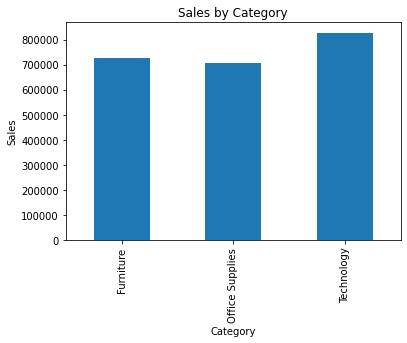

In [30]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(6,4))
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.ylabel('Sales')
plt.show()

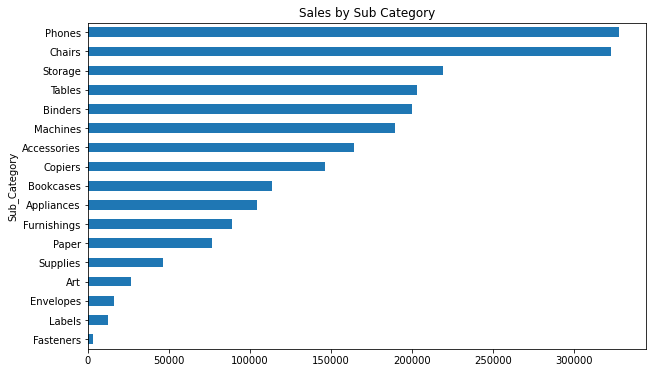

In [31]:
sub_sales = df.groupby('Sub_Category')['Sales'].sum().sort_values()

plt.figure(figsize=(10,6))
sub_sales.plot(kind='barh')
plt.title('Sales by Sub Category')
plt.show()

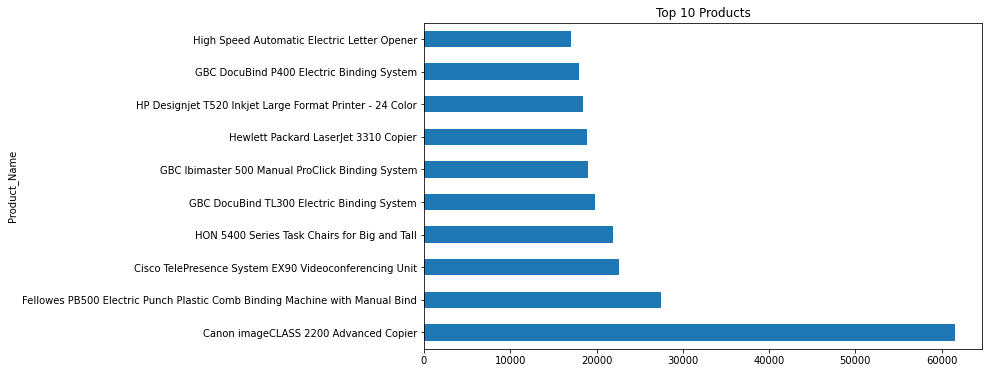

In [32]:
top_products = df.groupby('Product_Name')['Sales'].sum()\
                 .sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh')
plt.title('Top 10 Products')
plt.show()

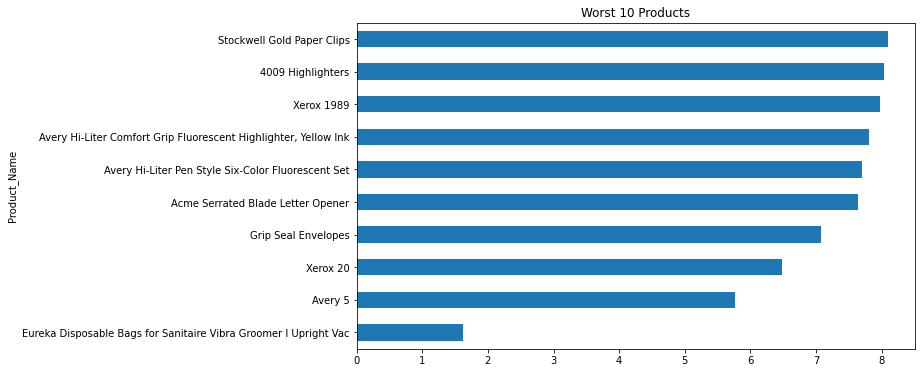

In [33]:
worst_products = df.groupby('Product_Name')['Sales'].sum()\
                   .sort_values().head(10)

plt.figure(figsize=(10,6))
worst_products.plot(kind='barh')
plt.title('Worst 10 Products')
plt.show()

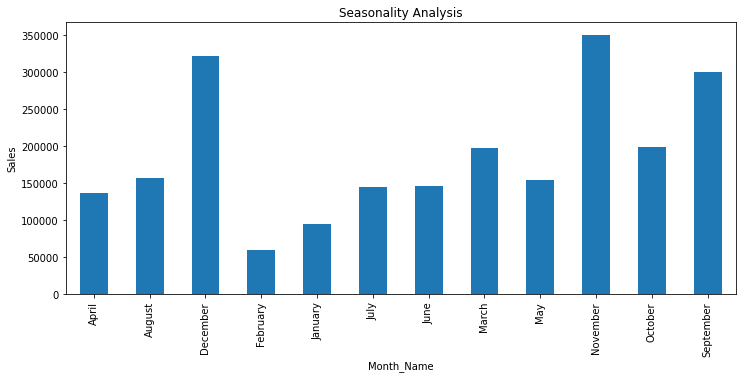

In [34]:
df['Month_Name'] = df['Order_Date'].dt.month_name()

seasonality = df.groupby('Month_Name')['Sales'].sum()

plt.figure(figsize=(12,5))
seasonality.plot(kind='bar')
plt.title('Seasonality Analysis')
plt.ylabel('Sales')
plt.show()

In [ ]:
write findings such as:
1.Highest sales region.
2.Lowest sales region.
3.Best selling category.
4.Worst selling category.
5.Top 10 products.
6.Worst 10 products.
7.Peak sales months.
8.Low sales months.

In [ ]:
5 Recommendations
1.Focus marketing on top-selling products.
2.Increase promotions in low-performing regions.
3.Bundle slow-moving products with best sellers.
4.Run campaigns during peak seasonal months.
5.Improve customer retention through loyalty offers.